In [1]:
import numpy as np 
import pickle 
import pandas as pd 
from sklearn.metrics import confusion_matrix
import re
%matplotlib inline 
import matplotlib.pyplot as plt 
import seaborn as sns
import yaml 
from pathlib import Path
import matplotlib
import re 
# matplotlib.rcParams.update({'font.size': 26})
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
import sys
sys.path.append('../')

In [2]:
### Get results from dir

param_decoding_results_dir = Path("parameter_decoding")
results_pkls = list(param_decoding_results_dir.rglob("*_r2_decoding_values.pkl"))

results_dfs = []
for ix, file_path in enumerate(results_pkls):
    results_dict = pd.read_pickle(file_path)
    if 'pr2_invariant' not in results_dict.keys():
        continue 

    results_df = pd.DataFrame.from_dict(results_dict)
    results_df['parameter'] = results_df.index
    results_df.reset_index(drop=True)
    results_df['layer'] = file_path.stem.split('_r2')[0]
    results_df['eq_lmbda'] = float(file_path.parent.stem.split('eq_lmbda_')[-1])
    eq_model_base_name = file_path.parent.stem.split('equivariant_')[-1]
    results_df['ssl_training'] = 'equi.: SNR + b.g.' if 'w_invar_augment' in eq_model_base_name else "equi.: SNR + b.g. + augment"
    results_dfs.append(results_df)

    # if ix == 0:
    #     # mock invariant scores from first model as lmbda = 0.0 
    invar_df = results_df.copy(deep=True) 
    invar_df['eq_lmbda'] = 0.0 
    invar_df['ssl_training'] = 'invar.'
    invar_df['r2_equivariant'] = invar_df['r2_invariant']
    invar_df['pr2_equivariant'] = invar_df['pr2_invariant']
    results_dfs.append(invar_df)


    # break

results = pd.concat(results_dfs, axis=0, ignore_index = True).drop_duplicates()

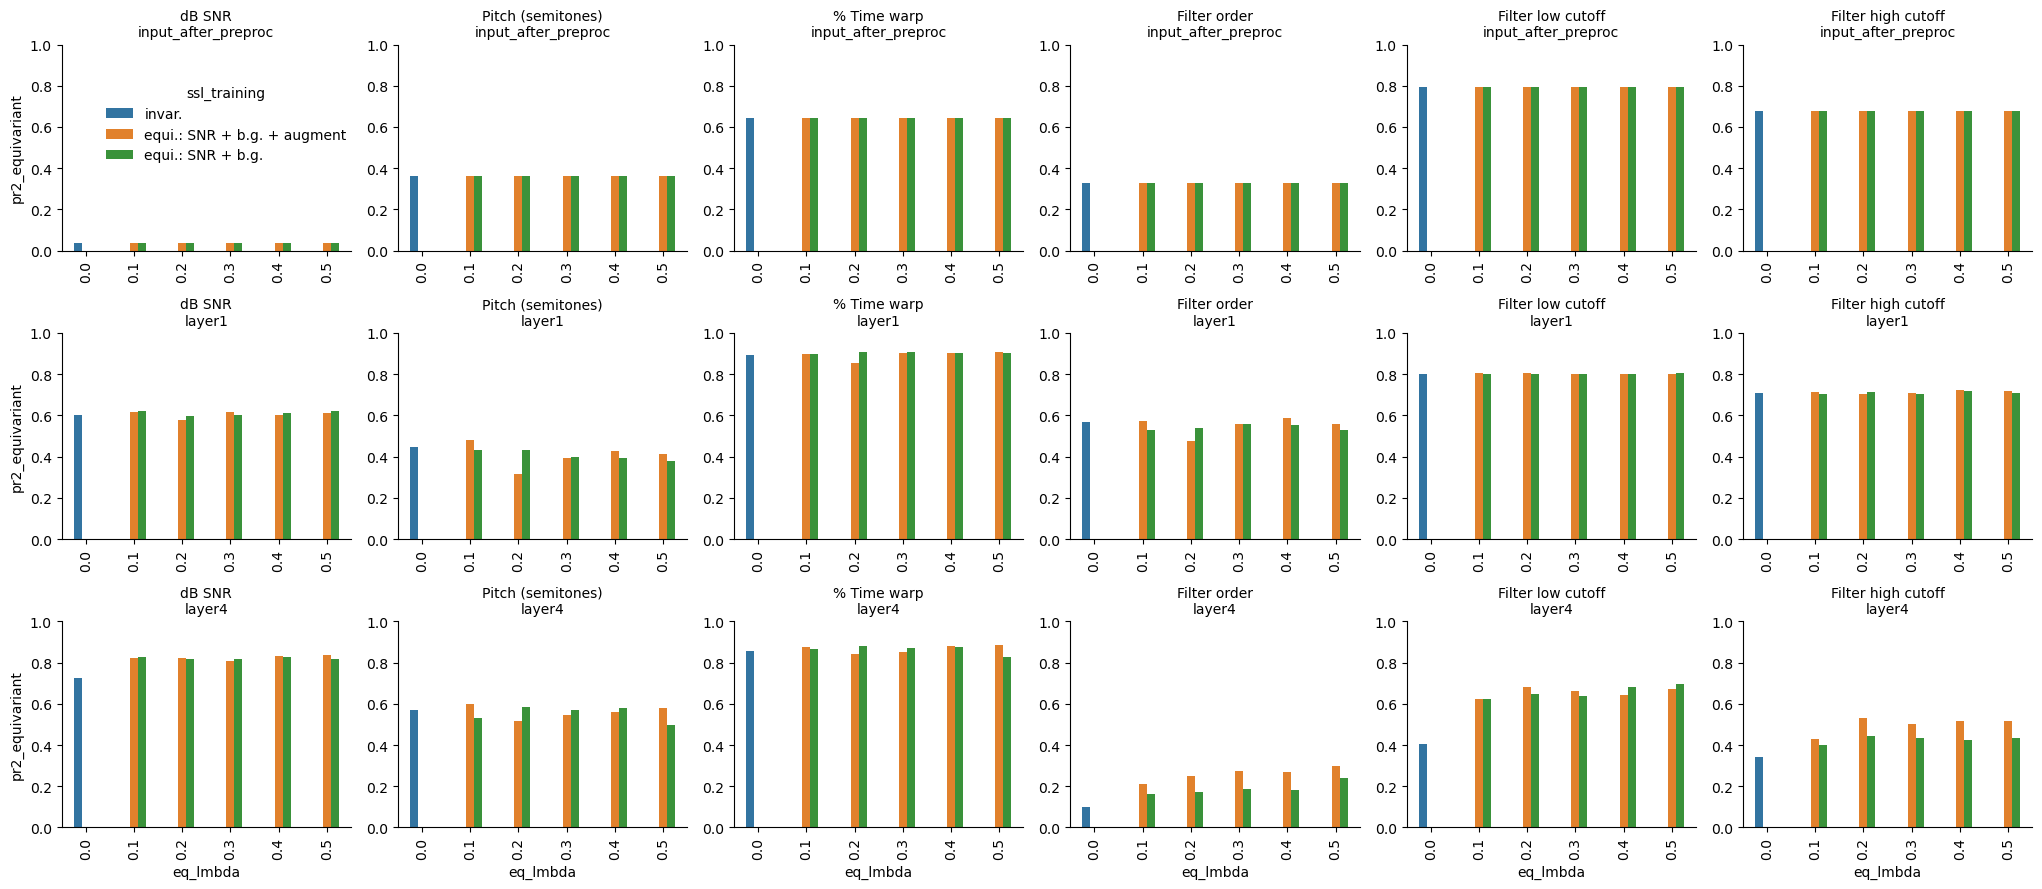

In [3]:
layer_order = [
            'input_after_preproc',
            'layer1',
            # 'layer2', 
            # 'layer3',
            'layer4',
            # 'avgpool'
]

eq_lmbda_order = sorted(results['eq_lmbda'].unique())

g = sns.catplot(data=results,
            kind = 'bar',
            x='eq_lmbda', 
            order=eq_lmbda_order,
            y='pr2_equivariant', 
            hue='ssl_training', 
            col='parameter',
            row='layer', 
            row_order=layer_order,
            sharey=False,
            sharex=False,
            width=0.5,
            height=3, aspect=1)

g.set_titles("{col_name}\n{row_name}")
g.set(ylim=(0,1))
g.set_xticklabels(labels=eq_lmbda_order, rotation=90)
leg = g._legend
leg.set_bbox_to_anchor([0.175, 0.85])

plt.tight_layout()


In [4]:
results[results.layer.str.contains('input') & (results.eq_lmbda.isin([0.1,0.5]))]


,r2_invariant,r2_equivariant,pr2_invariant,pr2_equivariant,parameter,layer,eq_lmbda,ssl_training
60,-0.388893,-0.388893,0.037284,0.037284,dB SNR,input_after_preproc,0.5,equi.: SNR + b.g. + augment
61,0.308179,0.308179,0.362452,0.362452,Pitch (semitones),input_after_preproc,0.5,equi.: SNR + b.g. + augment
62,0.619597,0.619597,0.644720,0.644720,% Time warp,input_after_preproc,0.5,equi.: SNR + b.g. + augment
63,0.222222,0.222222,0.328157,0.328157,Filter order,input_after_preproc,0.5,equi.: SNR + b.g. + augment
64,0.787379,0.787379,0.792888,0.792888,Filter low cutoff,input_after_preproc,0.5,equi.: SNR + b.g. + augment
65,0.660935,0.660935,0.676797,0.676797,Filter high cutoff,input_after_preproc,0.5,equi.: SNR + b.g. + augment
276,-0.388893,-0.388893,0.037284,0.037284,dB SNR,input_after_preproc,0.5,equi.: SNR + b.g.
277,0.308179,0.308179,0.362452,0.362452,Pitch (semitones),input_after_preproc,0.5,equi.: SNR + b.g.
278,0.619597,0.619597,0.644720,0.644720,% Time warp,input_after_preproc,0.5,equi.: SNR + b.g.
279,0.222222,0.222222,0.328157,0.328157,Filter order,input_after_preproc,0.5,equi.: SNR + b.g.


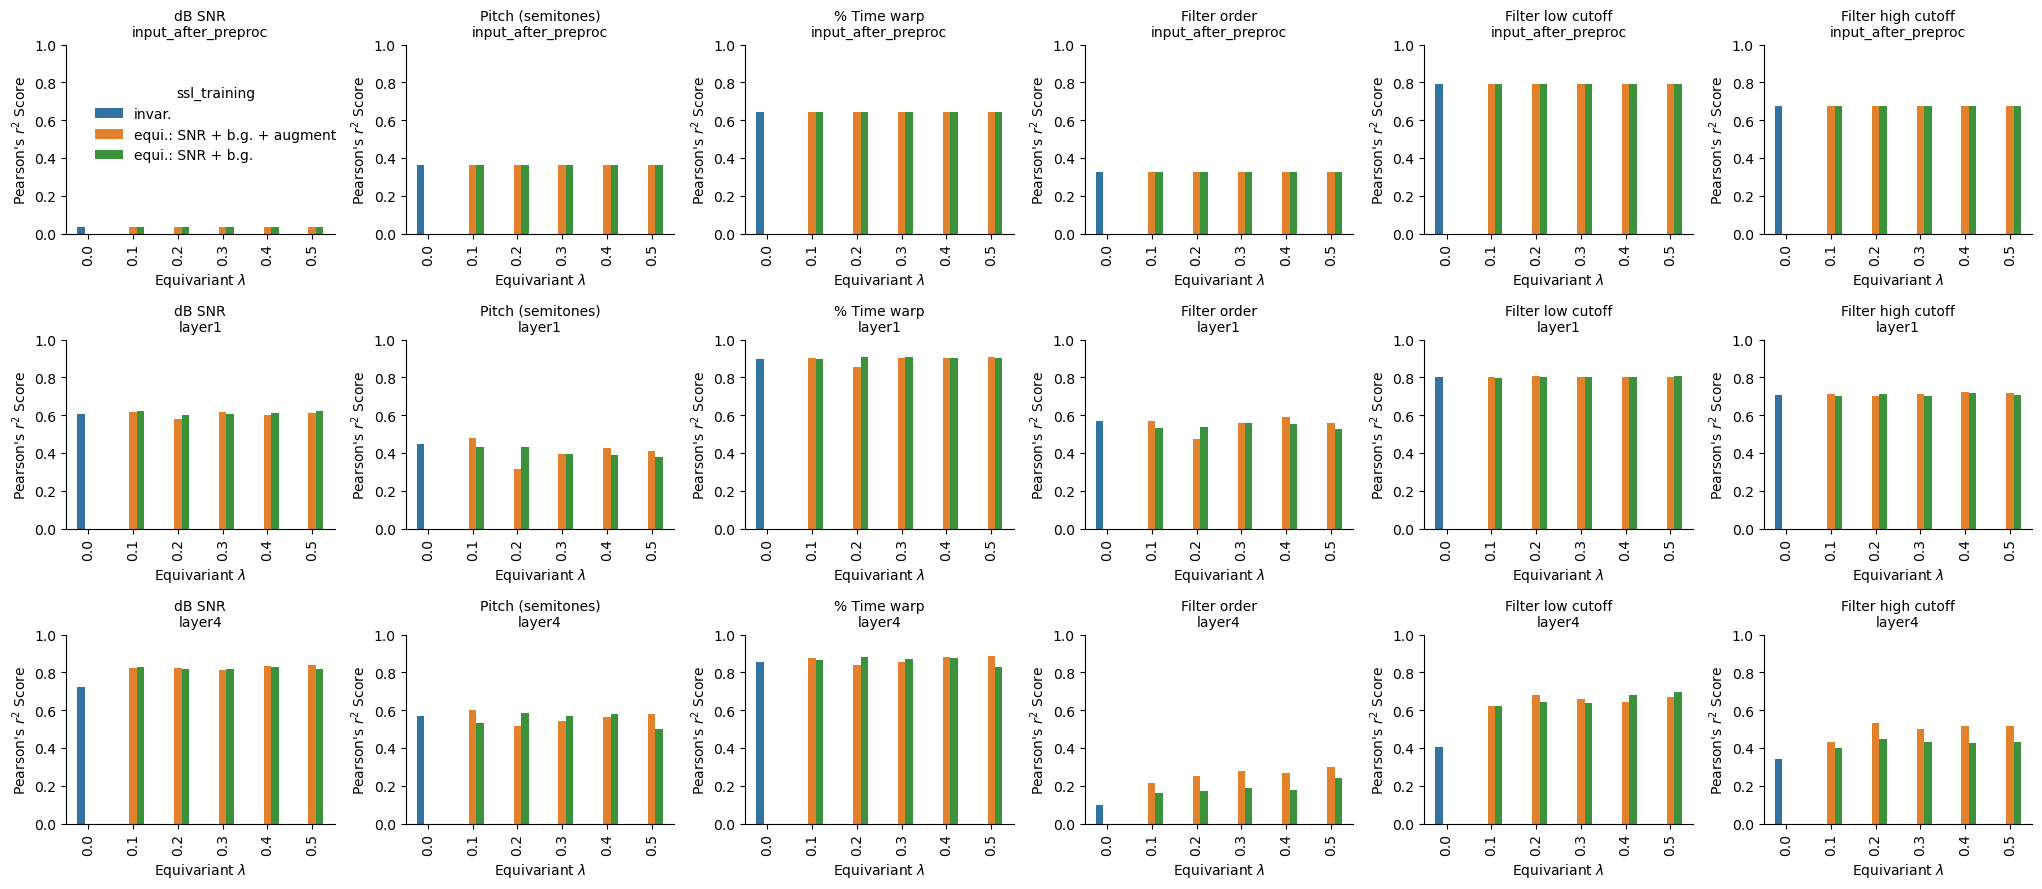

In [8]:
layer_order = [
            'input_after_preproc',
            'layer1',
            # 'layer2', 
            # 'layer3',
            'layer4',
            # 'avgpool'
]

eq_lmbda_order = sorted(results['eq_lmbda'].unique())
# eq_lmbda_order = [0.0, 0.1, 0.5]
g = sns.catplot(data=results,
            kind = 'bar',
            x='eq_lmbda', 
            order=eq_lmbda_order,
            y='pr2_equivariant', 
            hue='ssl_training', 
            col='parameter',
            row='layer', 
            row_order=layer_order,
            sharey=False,
            sharex=False,
            width=0.5,
            height=3, aspect=1)

g.set_titles("{col_name}\n{row_name}")
g.set(xlabel="Equivariant $\\lambda$", ylabel="Pearson's $r^2$ Score")
g.set(ylim=(0,1))
g.set_xticklabels(labels=eq_lmbda_order, rotation=90)
# Access the legend object
leg = g._legend

# Set the legend's position (adjust the coordinates as needed)
leg.set_bbox_to_anchor([0.17, 0.85])
plt.tight_layout()


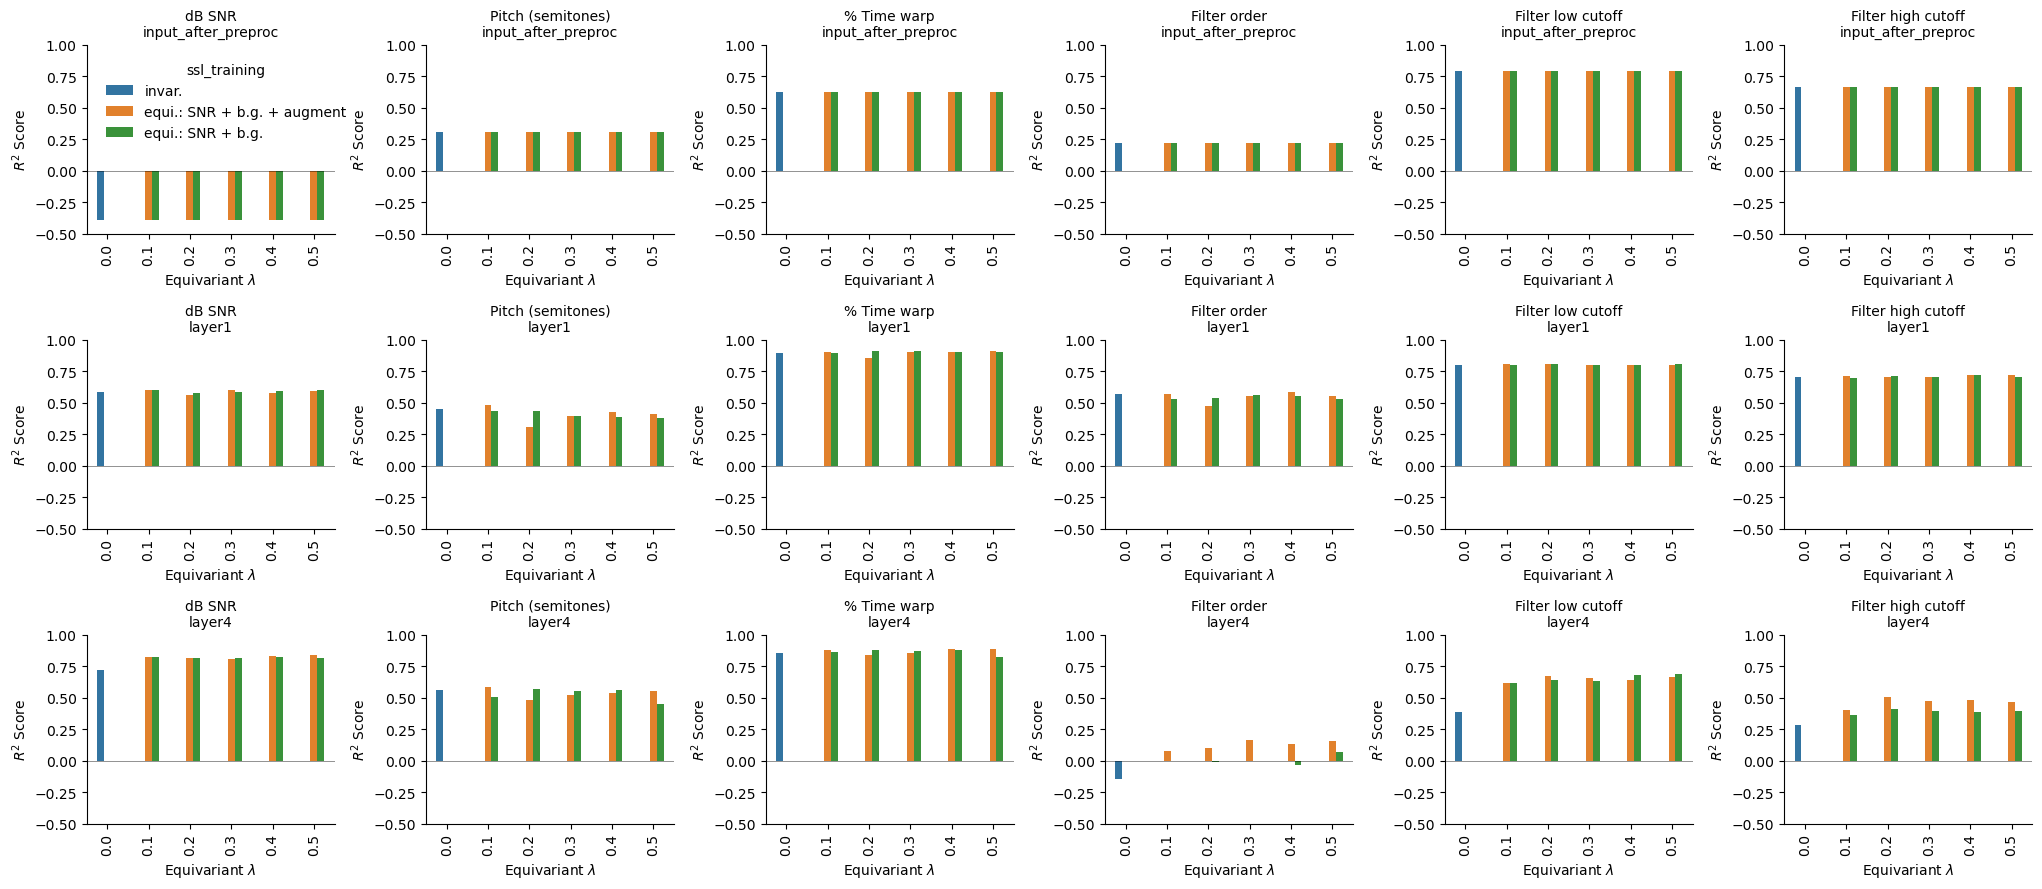

In [6]:
layer_order = [
            'input_after_preproc',
            'layer1',
            # 'layer2', 
            # 'layer3',
            'layer4',
            # 'avgpool'
]

eq_lmbda_order = sorted(results['eq_lmbda'].unique())
# eq_lmbda_order = [0.1, 0.5]

g = sns.catplot(data=results,
            kind = 'bar',
            x='eq_lmbda', 
            order=eq_lmbda_order,
            y='r2_equivariant', 
            hue='ssl_training', 
            col='parameter',
            row='layer', 
            row_order=layer_order,
            sharey=False,
            sharex=False,
            width=0.5,
            height=3, aspect=1)

g.set_titles("{col_name}\n{row_name}")
g.set(ylim=(-0.5,1))
g.set(xlabel="Equivariant $\\lambda$", ylabel="$R^2$ Score")
g.set_xticklabels(labels=eq_lmbda_order, rotation=90)
g.refline(y=0, color='k', linestyle='-', alpha=0.6, linewidth=0.5)

# Access the legend object
leg = g._legend

# Set the legend's position (adjust the coordinates as needed)
leg.set_bbox_to_anchor([0.175, 0.875])
plt.tight_layout()


## Compare invariant and equivariant heads 

In [27]:
aug_data

{'r2_invariant_head': {'dB SNR': -0.035117149353027344,
  'Pitch (semitones)': 0.2762989892725687,
  '% Time warp': -0.04268703944914076,
  'Filter order': -0.14995786712992332,
  'Filter low cutoff': -0.005775035948291318,
  'Filter high cutoff': -0.13707814765333093},
 'r2_equivariant_head': {'dB SNR': 0.48312175273895264,
  'Pitch (semitones)': -0.1093196797026017,
  '% Time warp': 0.5234612317073812,
  'Filter order': 0.09432791412176866,
  'Filter low cutoff': 0.6608893127486261,
  'Filter high cutoff': 0.5605932760571101},
 'pr2_invariant_head': {'dB SNR': np.float64(0.11589054266638048),
  'Pitch (semitones)': np.float64(0.3350461606587383),
  '% Time warp': np.float64(0.07798002240251278),
  'Filter order': np.float64(0.02363970625998655),
  'Filter low cutoff': np.float64(0.09267898562250877),
  'Filter high cutoff': np.float64(0.03184167976153515)},
 'pr2_equivariant_head': {'dB SNR': np.float64(0.5077268883841509),
  'Pitch (semitones)': np.float64(0.06334213444472113),
  '%

In [28]:
no_aug_data

{'r2_invariant_head': {'dB SNR': -0.01016545295715332,
  'Pitch (semitones)': 0.3848582299123129,
  '% Time warp': 0.1989400962771779,
  'Filter order': -0.11597425561257335,
  'Filter low cutoff': 0.00721811420080809,
  'Filter high cutoff': -0.1958908669060695},
 'r2_equivariant_head': {'dB SNR': 0.48345112800598145,
  'Pitch (semitones)': -0.1965758243744058,
  '% Time warp': 0.426326499089579,
  'Filter order': 0.17169857254488663,
  'Filter low cutoff': 0.6778811602476309,
  'Filter high cutoff': 0.5846140053115944},
 'pr2_invariant_head': {'dB SNR': np.float64(0.15025765569084545),
  'Pitch (semitones)': np.float64(0.41349249121905274),
  '% Time warp': np.float64(0.2498430234913509),
  'Filter order': np.float64(0.03156993069059247),
  'Filter low cutoff': np.float64(0.11628153878875148),
  'Filter high cutoff': np.float64(0.025817366975196022)},
 'pr2_equivariant_head': {'dB SNR': np.float64(0.5055079409938208),
  'Pitch (semitones)': np.float64(0.03292508731832887),
  '% Time 

In [37]:
eq_lmbda = 0.5


f'resnet18_barlow_equivariant_lmbda_1e-2_lr_2e-1_w_invar_augment_no_avgpool_eq_lmbda_{eq_lmbda:.0e}'

'resnet18_barlow_equivariant_lmbda_1e-2_lr_2e-1_w_invar_augment_no_avgpool_eq_lmbda_5e-01'

In [44]:
aug_data

{'r2_invariant_head': {'dB SNR': -0.01642751693725586,
  'Pitch (semitones)': 0.30877910912950934,
  '% Time warp': -0.1372045655689318,
  'Filter order': -0.08572792599715617,
  'Filter low cutoff': 0.03575562772143526,
  'Filter high cutoff': -0.1722711413542759},
 'r2_equivariant_head': {'dB SNR': -3715.541259765625,
  'Pitch (semitones)': -99638.03408952613,
  '% Time warp': -1131.9973984219291,
  'Filter order': -203.99659551492272,
  'Filter low cutoff': -2897.116740916215,
  'Filter high cutoff': -2534.3599288216747},
 'pr2_invariant_head': {'dB SNR': np.float64(0.15528546747246655),
  'Pitch (semitones)': np.float64(0.3437164079577615),
  '% Time warp': np.float64(0.04147961379374026),
  'Filter order': np.float64(0.04153467260273051),
  'Filter low cutoff': np.float64(0.09843602630019545),
  'Filter high cutoff': np.float64(0.013027704302355482)},
 'pr2_equivariant_head': {'dB SNR': np.float64(0.0005811325039994813),
  'Pitch (semitones)': np.float64(-7.614966245363227e-05),
 

In [47]:
aug_data

{'r2_invariant_head': {'dB SNR': -0.01642751693725586,
  'Pitch (semitones)': 0.30877910912950934,
  '% Time warp': -0.1372045655689318,
  'Filter order': -0.08572792599715617,
  'Filter low cutoff': 0.03575562772143526,
  'Filter high cutoff': -0.1722711413542759},
 'r2_equivariant_head': {'dB SNR': -3715.541259765625,
  'Pitch (semitones)': -99638.03408952613,
  '% Time warp': -1131.9973984219291,
  'Filter order': -203.99659551492272,
  'Filter low cutoff': -2897.116740916215,
  'Filter high cutoff': -2534.3599288216747},
 'pr2_invariant_head': {'dB SNR': np.float64(0.15528546747246655),
  'Pitch (semitones)': np.float64(0.3437164079577615),
  '% Time warp': np.float64(0.04147961379374026),
  'Filter order': np.float64(0.04153467260273051),
  'Filter low cutoff': np.float64(0.09843602630019545),
  'Filter high cutoff': np.float64(0.013027704302355482)},
 'pr2_equivariant_head': {'dB SNR': np.float64(0.0005811325039994813),
  'Pitch (semitones)': np.float64(-7.614966245363227e-05),
 

KeyError: 'pr2_invariant_head'

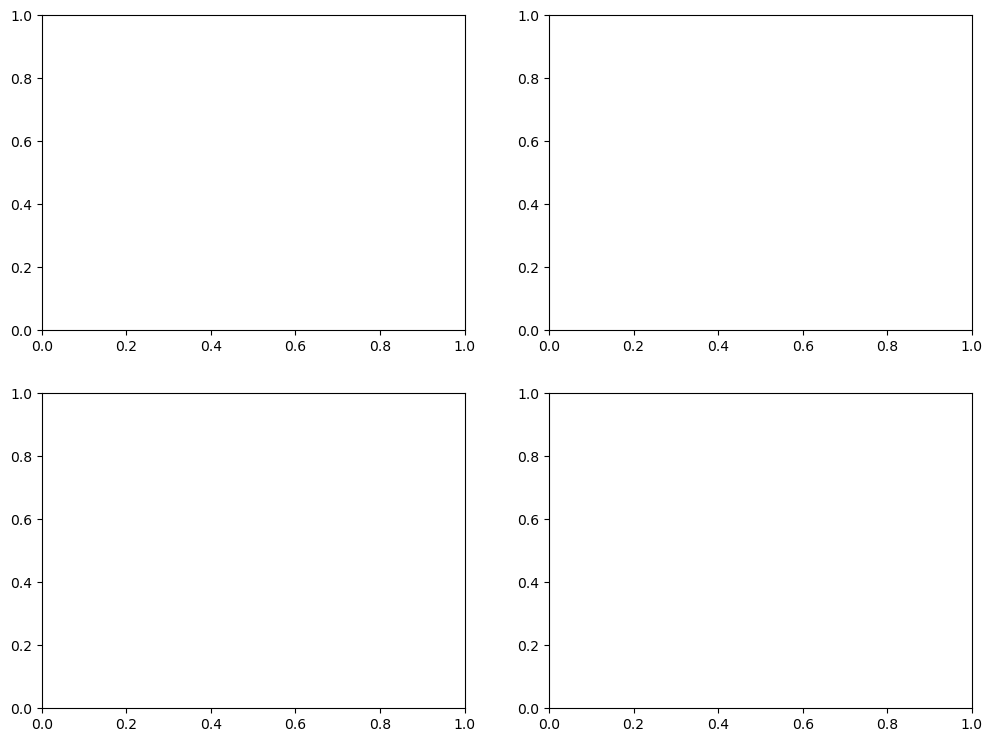

In [53]:
eq_lmbda = 0.2


no_aug_base = f'resnet18_barlow_equivariant_lmbda_1e-2_lr_2e-1_w_invar_augment_no_avgpool_eq_lmbda_{eq_lmbda:.0e}'
pd_fname  = Path('parameter_decoding') / f"{no_aug_base}" / f"invar_equivar_ssl_head_r2_decoding_values.pkl"

no_aug_data = pd.read_pickle(pd_fname)

w_aug_base = f'resnet18_barlow_equivariant_lmbda_1e-2_lr_2e-1_no_avgpool_eq_lmbda_{eq_lmbda:.0e}'
aug_pd_fname  = Path('parameter_decoding') / f"{w_aug_base}" / f"invar_equivar_ssl_head_r2_decoding_values.pkl"

aug_data = pd.read_pickle(aug_pd_fname)


fig, axs = plt.subplots(2, 2, figsize=(12,9))
# axs = axs[0,:]
# paxs = axs[1,:]

bar_width = 0.25
param_names = list(aug_data['pr2_invariant_head'].keys())
bar_x = np.arange(len(param_names))
tasks = ['invariant', 'equivariant']

for ix, head in enumerate(tasks):
    for jx, score in enumerate(['r2', 'pr2']):
        axs[jx, ix].bar(bar_x, aug_data[f"{score}_{head}"].values(), color='tab:pink', label='SNR + b.g. + augs', width=bar_width)
        axs[jx, ix].bar(bar_x + bar_width, no_aug_data[f"{score}_{head}"].values(), color='tab:grey', label='SNR + b.g', width=bar_width)
        axs[jx, ix].axhline(0, color='k', lw=0.5)
        axs[jx, ix].set_xticks(rotation=45, ticks=bar_x + (bar_width * 0.5), labels=param_names)
        axs[jx, ix].set_xlabel('Augmentation')
        axs[jx, ix].legend(loc='upper left', frameon=False)

        if jx == 0:
            axs[jx, ix].set_ylabel("$R^2$ Score")
        else:
            axs[jx, ix].set_ylabel("Pearson's $r^2$ Score")

        axs[jx, ix].set_ylim(-0.5,1)
        axs[jx, ix].set_title(f"{head.replace('_', ' ').title()}")

fig.suptitle(f"ResNet18 Equivariant $\\lambda$ {eq_lmbda}")
plt.tight_layout()